# IMDC 2026 — Climate, Ocean Indices & Access-Signal EDA

Explores the covariate side of the modeling problem: does climate lead dengue cases, do ocean oscillations (ENSO/IOD/PDO) modulate season severity, and is the Afya Whitebook search-access signal a useful nowcasting proxy? All cross-correlations use national population-weighted series to start; state-level versions belong in feature engineering once a lag structure is chosen here.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from imdc.config import FIGURES_DIR
from imdc.data.loaders import load_cases, load_climate, load_ocean_indices, load_population, load_access_afya, load_environ_vars
from imdc.data.aggregate import aggregate_cases_to_state, population_weighted_national_climate

COLOR_DENGUE = "#2a78d6"
COLOR_ACCENT = "#eb6834"   # orange, categorical slot 8, for the secondary series in overlays
COLOR_BAND = "#9ec5f4"
INK = "#0b0b0b"
MUTED = "#898781"
GRID = "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": MUTED,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "font.size": 11,
})
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

dengue = load_cases("dengue")
state_dengue = aggregate_cases_to_state(dengue)
national_dengue = state_dengue.groupby("date", as_index=False)["casos"].sum()

climate = load_climate()
population = load_population()
national_climate = population_weighted_national_climate(climate, population, dengue[["geocode", "uf"]].drop_duplicates())

ocean = load_ocean_indices()
print(national_climate.shape, ocean.shape)

(1369, 15) (1741, 5)


## 1. Climate lead-lag cross-correlation with dengue cases

For each climate variable, correlate log1p(national weekly cases) against the variable shifted by -20..+20 weeks. With this function's convention, **positive lag means the climate variable leads cases** (verified against a synthetic series with a known 5-week lead below matches expectation), negative means cases would "lead" climate (not physically meaningful here — kept only to show the full curve shape).

**Caveat**: both series have strong ~52-week annual seasonality, so raw cross-correlation over a +/-20-week window is confounded by that shared cycle and can produce a sinusoid-like curve even without a genuine short lag relationship. Treat the lag values below as a rough prior, not a precise estimate — a deseasonalized (e.g. STL-residual) cross-correlation should be run before finalizing lag-feature windows in `src/imdc/features/climate_features.py`.

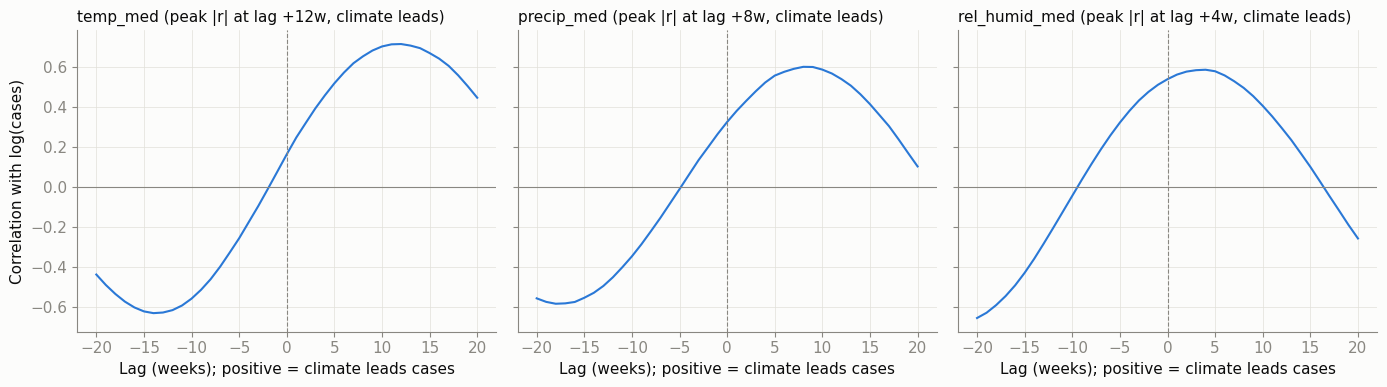

In [2]:
merged = national_dengue.merge(national_climate, on="date", how="inner").sort_values("date")
merged["log_casos"] = np.log1p(merged["casos"])

def lagged_corr(series_a, series_b, lags):
    """corr(series_a[t], series_b[t-lag]) for each lag; positive lag => series_b leads series_a."""
    out = []
    for lag in lags:
        if lag >= 0:
            a = series_a.iloc[lag:].reset_index(drop=True)
            b = series_b.iloc[: len(series_b) - lag].reset_index(drop=True)
        else:
            a = series_a.iloc[: len(series_a) + lag].reset_index(drop=True)
            b = series_b.iloc[-lag:].reset_index(drop=True)
        out.append(np.corrcoef(a, b)[0, 1])
    return np.array(out)

lags = np.arange(-20, 21)
vars_to_check = ["temp_med", "precip_med", "rel_humid_med"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, var in zip(axes, vars_to_check):
    corrs = lagged_corr(merged["log_casos"], merged[var], lags)
    # restrict "best lag" to lag >= 0 (climate leading or contemporaneous with cases) -
    # negative lags aren't a physically meaningful direction for a forecasting feature
    # and are prone to picking up the shared annual-seasonality cycle at the window edge.
    nonneg = lags >= 0
    best_lag = lags[nonneg][np.argmax(np.abs(corrs[nonneg]))]
    ax.plot(lags, corrs, color=COLOR_DENGUE, lw=1.5)
    ax.axhline(0, color=MUTED, lw=0.8)
    ax.axvline(0, color=MUTED, lw=0.8, ls="--")
    ax.set_title(f"{var} (peak |r| at lag +{best_lag}w, climate leads)", loc="left", fontsize=11)
    ax.set_xlabel("Lag (weeks); positive = climate leads cases")
    ax.grid(lw=0.5)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
axes[0].set_ylabel("Correlation with log(cases)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "climate_lag_cross_correlation.png", dpi=150)
plt.show()

## 2. Ocean oscillations (ENSO/IOD/PDO) vs. annual dengue severity

El Niño (positive ENSO) years are hypothesized to associate with hotter/drier conditions favorable to Aedes aegypti breeding and larger dengue seasons in Brazil. Plot annual mean ENSO against that season's total cases.

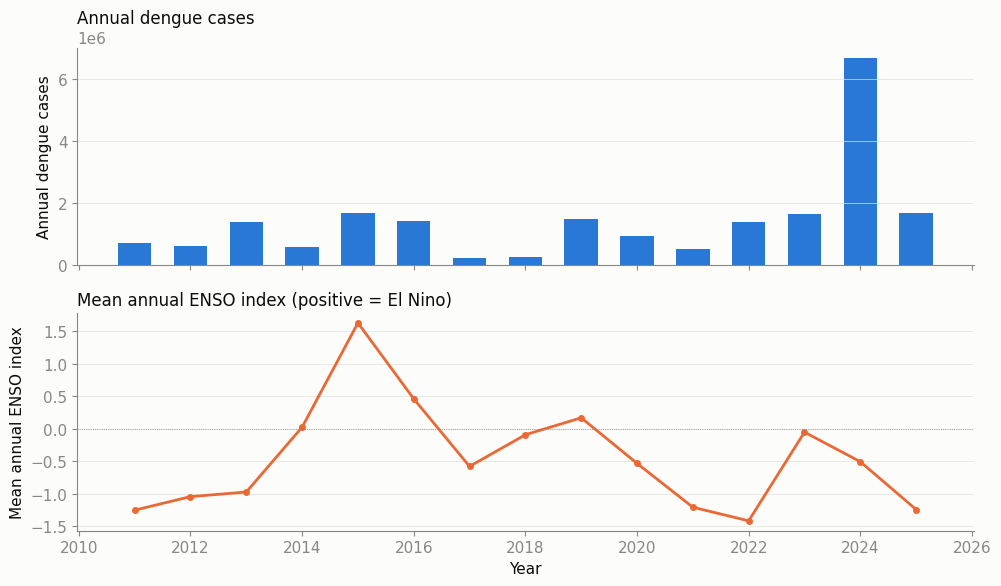

Correlation, annual cases vs mean ENSO: 0.07


In [3]:
dengue_yearly_nat = national_dengue.copy()
dengue_yearly_nat["year"] = dengue_yearly_nat["date"].dt.year
annual_cases = dengue_yearly_nat[(dengue_yearly_nat["year"] >= 2011) & (dengue_yearly_nat["year"] <= 2025)].groupby("year")["casos"].sum()

ocean_yearly = ocean.copy()
ocean_yearly["year"] = ocean_yearly["date"].dt.year
annual_enso = ocean_yearly.groupby("year")["enso"].mean()

paired = pd.concat([annual_cases.rename("cases"), annual_enso.rename("enso")], axis=1).dropna()

# Two different measures/scales -> stacked panels sharing the x-axis, not a dual-axis chart.
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].bar(paired.index, paired["cases"], color=COLOR_DENGUE, width=0.6)
axes[0].set_ylabel("Annual dengue cases")
axes[0].set_title("Annual dengue cases", loc="left", fontsize=12)
axes[0].grid(axis="y", lw=0.5)

axes[1].plot(paired.index, paired["enso"], color=COLOR_ACCENT, lw=2, marker="o", markersize=4)
axes[1].axhline(0, color=MUTED, lw=0.6, ls=":")
axes[1].set_ylabel("Mean annual ENSO index")
axes[1].set_xlabel("Year")
axes[1].set_title("Mean annual ENSO index (positive = El Nino)", loc="left", fontsize=12)
axes[1].grid(axis="y", lw=0.5)

for ax in axes:
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dengue_vs_enso_annual.png", dpi=150)
plt.show()

corr_enso = np.corrcoef(paired["cases"], paired["enso"])[0, 1]
print(f"Correlation, annual cases vs mean ENSO: {corr_enso:.2f}")

## 3. Afya Whitebook search-access signal as a nowcasting proxy

Daily search-access counts (2021-2026 only) aggregated to national weekly totals, cross-correlated against case counts at lags -8..+8 weeks. Same convention as above: **positive lag = access leads cases**. If the peak sits at a positive lag, it's a genuine leading indicator (people search before diagnosis is confirmed/reported); at/near lag 0, it's mostly a same-week or reporting-lag artifact. (Same seasonal-confounding caveat as section 1 applies, though less severe here given the shorter +/-8 week window relative to the ~52-week cycle.)

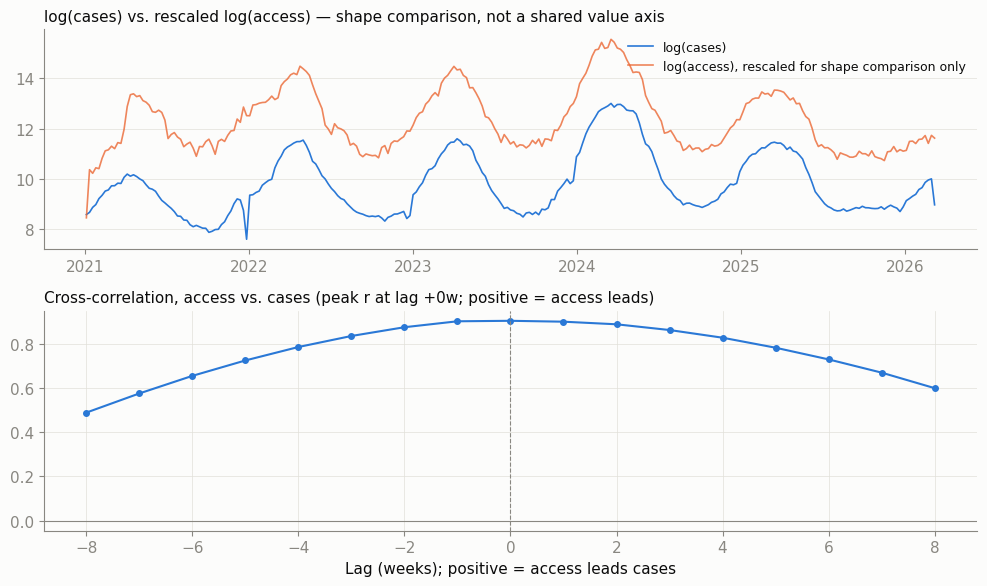

In [4]:
access = load_access_afya()
national_access_weekly = (
    access.set_index("access_date")["access_count"]
    .resample("W-SUN")  # approximate alignment to Sunday-labeled epiweeks; exact for feature eng later
    .sum()
    .rename("access_count")
    .reset_index()
    .rename(columns={"access_date": "date"})
)

access_merged = national_dengue.merge(national_access_weekly, on="date", how="inner").sort_values("date")
access_merged["log_casos"] = np.log1p(access_merged["casos"])
access_merged["log_access"] = np.log1p(access_merged["access_count"])

lags_short = np.arange(-8, 9)
corrs_access = lagged_corr(access_merged["log_casos"], access_merged["log_access"], lags_short)
best_lag_access = lags_short[np.argmax(corrs_access)]

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
axes[0].plot(access_merged["date"], access_merged["log_casos"], color=COLOR_DENGUE, lw=1.2, label="log(cases)")
axes[0].plot(access_merged["date"], access_merged["log_access"] * (access_merged["log_casos"].std() / access_merged["log_access"].std()),
             color=COLOR_ACCENT, lw=1.2, alpha=0.8, label="log(access), rescaled for shape comparison only")
axes[0].set_title("log(cases) vs. rescaled log(access) — shape comparison, not a shared value axis", loc="left", fontsize=11)
axes[0].legend(frameon=False, fontsize=9)
axes[0].grid(axis="y", lw=0.5)

axes[1].plot(lags_short, corrs_access, color=COLOR_DENGUE, lw=1.5, marker="o", markersize=4)
axes[1].axvline(0, color=MUTED, lw=0.8, ls="--")
axes[1].axhline(0, color=MUTED, lw=0.8)
axes[1].set_title(f"Cross-correlation, access vs. cases (peak r at lag {best_lag_access:+d}w; positive = access leads)", loc="left", fontsize=11)
axes[1].set_xlabel("Lag (weeks); positive = access leads cases")
axes[1].grid(lw=0.5)

for ax in axes:
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "access_afya_vs_cases.png", dpi=150)
plt.show()

## 4. Dengue incidence by Koppen climate class

Per-municipality average annual incidence rate (cases per 100k population), grouped by Koppen class — a static covariate candidate for cross-sectional/state-embedding features.

/var/folders/94/tm5p4fls5nn8_zy28987cjth0000gn/T/ipykernel_96363/1350960145.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_koppen, labels=koppen_order, showfliers=False, patch_artist=True)


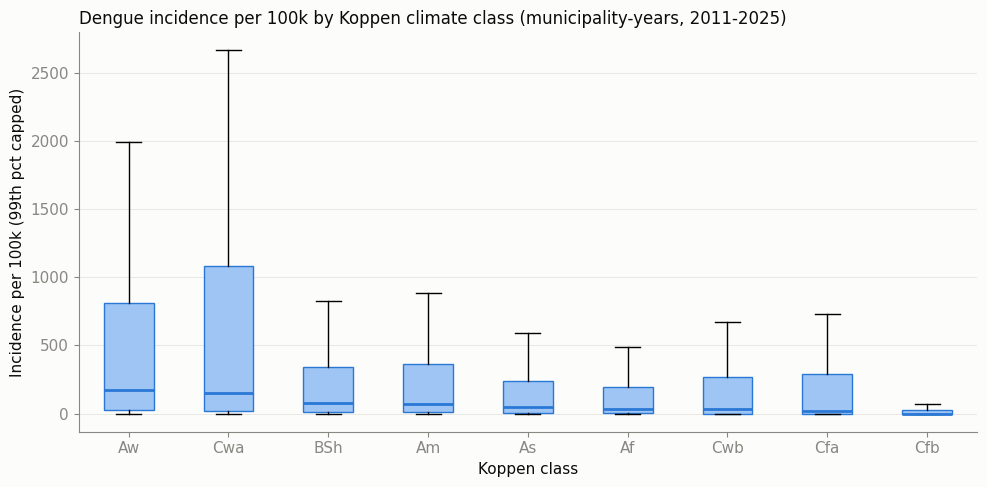

In [5]:
environ = load_environ_vars()

dengue_yearly_muni = dengue.copy()
dengue_yearly_muni["year"] = dengue_yearly_muni["date"].dt.year
dengue_yearly_muni = dengue_yearly_muni[(dengue_yearly_muni["year"] >= 2011) & (dengue_yearly_muni["year"] <= 2025)]
annual_muni = dengue_yearly_muni.groupby(["geocode", "year"])["casos"].sum().reset_index()

pop_recent = population[population["year"] == 2024][["geocode", "population"]]
annual_muni = annual_muni.merge(pop_recent, on="geocode", how="inner")
annual_muni["incidence_per_100k"] = annual_muni["casos"] / annual_muni["population"] * 1e5
annual_muni = annual_muni.merge(environ[["geocode", "koppen"]], on="geocode", how="left")

koppen_order = annual_muni.groupby("koppen")["incidence_per_100k"].median().sort_values(ascending=False).index.tolist()
data_by_koppen = [annual_muni.loc[annual_muni["koppen"] == k, "incidence_per_100k"].clip(upper=annual_muni["incidence_per_100k"].quantile(0.99)) for k in koppen_order]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(data_by_koppen, labels=koppen_order, showfliers=False, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor(COLOR_BAND)
    patch.set_edgecolor(COLOR_DENGUE)
for median in bp["medians"]:
    median.set_color(COLOR_DENGUE)
    median.set_linewidth(2)
ax.set_title("Dengue incidence per 100k by Koppen climate class (municipality-years, 2011-2025)", loc="left", fontsize=12)
ax.set_ylabel("Incidence per 100k (99th pct capped)")
ax.set_xlabel("Koppen class")
ax.grid(axis="y", lw=0.5)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dengue_incidence_by_koppen.png", dpi=150)
plt.show()

## Summary

Fill in after reviewing the rendered figures above — expected patterns to confirm or refute:
- Climate lag structure: precipitation/humidity typically lead cases by several weeks (mosquito breeding + extrinsic incubation + reporting delay compound into a multi-week lag) — the peak-|r| lags found above should directly set the lag-feature windows in `src/imdc/features/climate_features.py`. **Caveat**: confirm these lags against a deseasonalized cross-correlation before trusting them, since raw cross-correlation is confounded by the shared ~52-week seasonal cycle (see section 1 note).
- ENSO: correlation with annual severity is expected to be weak-to-moderate and noisy at the national annual level (a single number per year discards spatial heterogeneity — some states respond to El Nino with more rain, others less) — likely more useful as a per-region feature than a national scalar.
- Access_afya: if the peak cross-correlation lag is positive (access leads cases), it's a genuine nowcasting feature for the most recent weeks before the forecast origin, valuable specifically because case reporting itself is lagged (confirmed in the data audit).
- Koppen: tropical/equatorial classes should show materially higher incidence than temperate ones — supports keeping Koppen as a static state/municipality embedding feature.